In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [2]:
df = pd.read_csv("../Data/processed/ONE_SENSOR_TRAFIC_DATA_ONLY_ALL_YEARS.csv")

In [3]:
df = df.sort_values("timestamp").reset_index(drop=True)

split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Test:", test_df["timestamp"].min(), "→", test_df["timestamp"].max())
print(train_df.shape, test_df.shape)

Train: 2022-01-01 01:30:00 → 2024-02-07 07:40:00
Test: 2024-02-07 07:45:00 → 2024-12-31 21:55:00
(220812, 60) (94635, 60)


In [4]:
df.columns

Index(['flow', 'occupancy', 'speed', 'timestamp', 'sensor_index', 'sensor_id',
       'date', 'is_congested', 'congestion_30min', 'congestion_60min',
       'congestion_90min', 'congestion_120min', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'month', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'speed_lag_5m',
       'flow_lag_5m', 'occupancy_lag_5m', 'speed_lag_15m', 'flow_lag_15m',
       'occupancy_lag_15m', 'speed_lag_30m', 'flow_lag_30m',
       'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m', 'speed_roll_mean_15m', 'speed_roll_std_15m',
       'flow_roll_mean_15m', 'occupancy_roll_mean_15m', 'speed_roll_mean_30m',
       'speed_roll_std_30m', 'flow_roll_mean_30m', 'occupancy_roll_mean_30m',
       'speed_roll_mean_60m', 'speed_roll_std_60m', 'flow_roll_mean_60m',
       'occupancy_roll_mean_60m', 'speed_roll_mean_90m', 'speed_roll_std_90

In [5]:
target_cols = [
    "congestion_30min",
    "congestion_60min",
    "congestion_90min",
    "congestion_120min"
]

feature_cols = ['flow', 'occupancy', 'speed', 'is_congested', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos','month', 'month_cos','month_sin', 'speed_lag_5m', 'flow_lag_5m', 'occupancy_lag_5m',
       'speed_lag_15m', 'flow_lag_15m', 'occupancy_lag_15m', 'speed_lag_30m',
       'flow_lag_30m', 'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m', 'speed_roll_mean_15m', 'speed_roll_std_15m',
       'flow_roll_mean_15m', 'occupancy_roll_mean_15m', 'speed_roll_mean_30m',
       'speed_roll_std_30m', 'flow_roll_mean_30m', 'occupancy_roll_mean_30m',
       'speed_roll_mean_60m', 'speed_roll_std_60m', 'flow_roll_mean_60m',
       'occupancy_roll_mean_60m', 'speed_roll_mean_90m', 'speed_roll_std_90m',
       'flow_roll_mean_90m', 'occupancy_roll_mean_90m', 'speed_diff_5m',
       'speed_diff_15m', 'speed_diff_30m', 'occupancy_diff_5m',
       'occupancy_diff_15m']

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

baseline_results = []

for target in target_cols:
    y_true = test_df[target]
    
    # Baseline: asumo que el futuro será igual al estado actual
    y_pred = test_df["is_congested"]
    
    baseline_results.append({
        "target": target,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean()
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,target,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,congestion_30min,0.925736,0.823479,0.823727,0.823603,0.210472,0.210535
1,congestion_60min,0.894183,0.748394,0.748845,0.748619,0.210408,0.210535
2,congestion_90min,0.865420,0.679934,0.680549,0.680241,0.210345,0.210535
3,congestion_120min,0.840883,0.621512,0.622261,0.621886,0.210282,0.210535


In [7]:
target = "congestion_30min"

y_true = test_df[target]
y_pred = test_df["is_congested"]

cm = confusion_matrix(y_true, y_pred)

cm

array([[71200,  3517],
       [ 3511, 16407]])

In [8]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

early_warning_results = []

for target in target_cols:
    y_true = early_test_df[target]
    
    # Persistence baseline en casos no congestionados ahora siempre predice 0
    y_pred = early_test_df["is_congested"]
    
    early_warning_results.append({
        "target": target,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "n_rows": len(early_test_df)
    })

early_warning_results_df = pd.DataFrame(early_warning_results)

early_warning_results_df

,target,accuracy,precision,recall,f1,positive_rate_true,n_rows
0,congestion_30min,0.953006,0.0,0.0,0.0,0.046994,74711
1,congestion_60min,0.933062,0.0,0.0,0.0,0.066938,74711
2,congestion_90min,0.914885,0.0,0.0,0.0,0.085115,74711
3,congestion_120min,0.899386,0.0,0.0,0.0,0.100614,74711


El baseline de persistencia no sirve para detectar congestión antes de que ocurra. Si el tráfico todavía no está congestionado, siempre predice que seguirá normal. Por eso tiene recall 0 en los casos de early warning.

In [9]:
train_df[feature_cols].isna().sum()[train_df[feature_cols].isna().sum() > 0]

Series([], dtype: int64)

In [10]:
train_df["occupancy_lag_90m"]

0         0.0101
1         0.0084
2         0.0138
3         0.0137
4         0.0211
           ...  
220807    0.3254
220808    0.3018
220809    0.3379
220810    0.3378
220811    0.2809
Name: occupancy_lag_90m, Length: 220812, dtype: float64

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_models = {}
logreg_results = []

for target in target_cols:
    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    logreg_models[target] = model

    logreg_results.append({
        "target": target,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "positive_rate_true": y_test.mean(),
        "positive_rate_pred": y_pred.mean()
    })

logreg_results_df = pd.DataFrame(logreg_results)

logreg_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred
0,congestion_30min,0.821261,0.542660,0.958932,0.693096,0.953857,0.210472,0.371924
1,congestion_60min,0.806816,0.523243,0.921404,0.667455,0.929471,0.210408,0.370518
2,congestion_90min,0.801754,0.516277,0.912238,0.659380,0.913703,0.210345,0.371670
3,congestion_120min,0.798975,0.512284,0.917889,0.657571,0.906515,0.210282,0.376774


In [12]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

logreg_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    logreg_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

logreg_early_results_df = pd.DataFrame(logreg_early_results)

logreg_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.818675,0.179525,0.800627,0.293286,0.889054,0.046994,0.209581,74711
1,congestion_60min,0.813869,0.229742,0.756849,0.352486,0.873949,0.066938,0.220516,74711
2,congestion_90min,0.813107,0.286380,0.801541,0.421989,0.875580,0.085115,0.238225,74711
3,congestion_120min,0.813187,0.333471,0.857789,0.480244,0.885169,0.100614,0.258811,74711


In [13]:
comparison = baseline_results_df.merge(
    logreg_results_df,
    on="target",
    suffixes=("_baseline", "_logreg")
)

comparison[
    [
        "target",
        "accuracy_baseline",
        "accuracy_logreg",
        "precision_baseline",
        "precision_logreg",
        "recall_baseline",
        "recall_logreg",
        "f1_baseline",
        "f1_logreg",
        "roc_auc"
    ]
]

,target,accuracy_baseline,accuracy_logreg,precision_baseline,precision_logreg,recall_baseline,recall_logreg,f1_baseline,f1_logreg,roc_auc
0,congestion_30min,0.925736,0.821261,0.823479,0.542660,0.823727,0.958932,0.823603,0.693096,0.953857
1,congestion_60min,0.894183,0.806816,0.748394,0.523243,0.748845,0.921404,0.748619,0.667455,0.929471
2,congestion_90min,0.865420,0.801754,0.679934,0.516277,0.680549,0.912238,0.680241,0.659380,0.913703
3,congestion_120min,0.840883,0.798975,0.621512,0.512284,0.622261,0.917889,0.621886,0.657571,0.906515


In [14]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

logreg_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    logreg_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

logreg_early_results_df = pd.DataFrame(logreg_early_results)

logreg_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.818675,0.179525,0.800627,0.293286,0.889054,0.046994,0.209581,74711
1,congestion_60min,0.813869,0.229742,0.756849,0.352486,0.873949,0.066938,0.220516,74711
2,congestion_90min,0.813107,0.286380,0.801541,0.421989,0.875580,0.085115,0.238225,74711
3,congestion_120min,0.813187,0.333471,0.857789,0.480244,0.885169,0.100614,0.258811,74711


In [15]:
threshold_results = []

early_test_df = test_df[test_df["is_congested"] == 0].copy()

thresholds = np.arange(0.10, 1, 0.05)

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_true = early_test_df[target]
    y_proba = model.predict_proba(X_early)[:, 1]

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        threshold_results.append({
            "target": target,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "positive_rate_pred": y_pred.mean(),
            "positive_rate_true": y_true.mean()
        })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.head()

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
0,congestion_30min,0.10,0.704207,0.132154,0.951011,0.232060,0.338183,0.046994
1,congestion_30min,0.15,0.732101,0.142151,0.933637,0.246735,0.308656,0.046994
2,congestion_30min,0.20,0.750679,0.149020,0.913985,0.256259,0.288231,0.046994
3,congestion_30min,0.25,0.764506,0.154574,0.897465,0.263726,0.272851,0.046994
4,congestion_30min,0.30,0.775950,0.159107,0.879237,0.269454,0.259694,0.046994


In [16]:
best_f1_thresholds = (
    threshold_results_df
    .sort_values(["target", "f1"], ascending=[True, False])
    .groupby("target")
    .head(1)
)

best_f1_thresholds

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
64,congestion_120min,0.60,0.832488,0.350413,0.778768,0.483342,0.223608,0.100614
12,congestion_30min,0.70,0.869323,0.214103,0.666762,0.324126,0.146351,0.046994
28,congestion_60min,0.60,0.835714,0.242293,0.683663,0.357786,0.188874,0.066938
45,congestion_90min,0.55,0.823681,0.292913,0.757824,0.422515,0.220209,0.085115


In [17]:
high_recall_thresholds = (
    threshold_results_df[threshold_results_df["recall"] >= 0.85]
    .sort_values(["target", "precision"], ascending=[True, False])
    .groupby("target")
    .head(1)
)

high_recall_thresholds

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
62,congestion_120min,0.50,0.813187,0.333471,0.857789,0.480244,0.258811,0.100614
5,congestion_30min,0.35,0.787274,0.164517,0.864711,0.276440,0.247005,0.046994
23,congestion_60min,0.35,0.777409,0.214177,0.871226,0.343829,0.272289,0.066938
42,congestion_90min,0.40,0.790258,0.272692,0.878283,0.416170,0.274136,0.085115


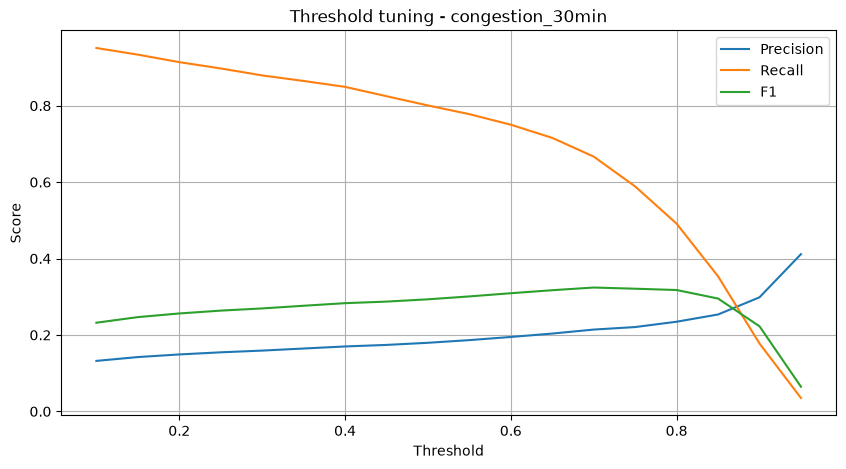

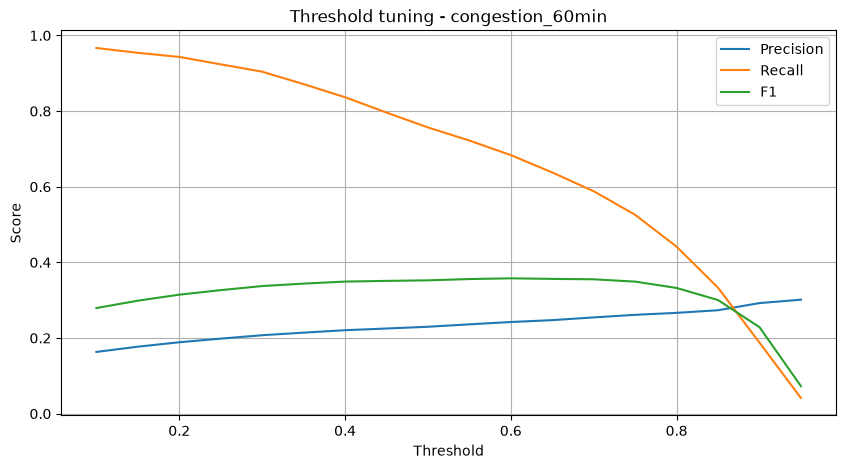

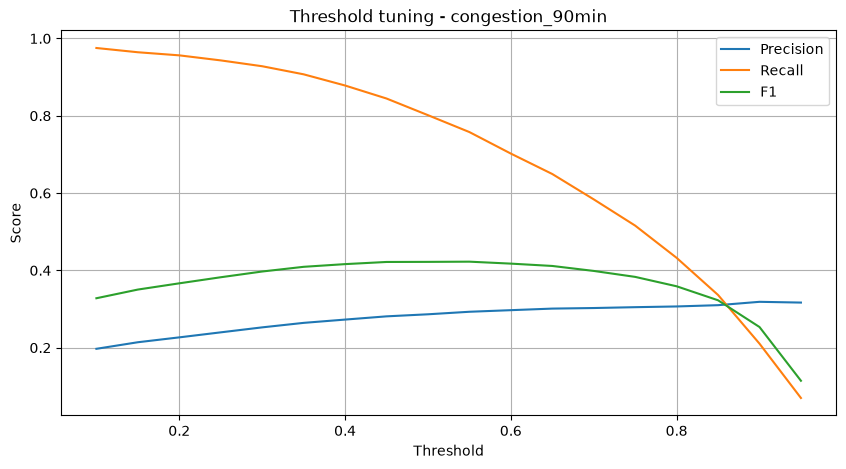

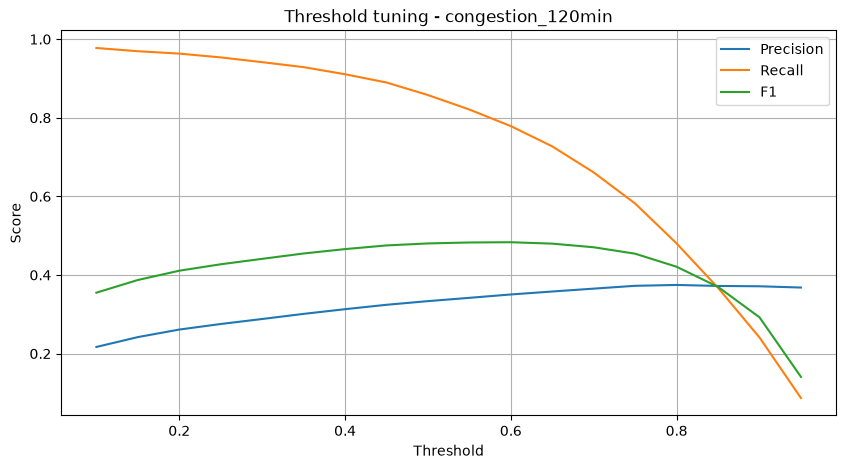

In [18]:
import matplotlib.pyplot as plt

for target in target_cols:
    temp = threshold_results_df[threshold_results_df["target"] == target]

    plt.figure(figsize=(10, 5))
    plt.plot(temp["threshold"], temp["precision"], label="Precision")
    plt.plot(temp["threshold"], temp["recall"], label="Recall")
    plt.plot(temp["threshold"], temp["f1"], label="F1")

    plt.title(f"Threshold tuning - {target}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
OPERATIONAL_THRESHOLD = 0.4

tuned_results = []

for target in target_cols:
    model = logreg_models[target]

    X_test = test_df[feature_cols]
    y_true = test_df[target]

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= OPERATIONAL_THRESHOLD).astype(int)

    tuned_results.append({
        "target": target,
        "threshold": OPERATIONAL_THRESHOLD,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean()
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,target,threshold,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,congestion_30min,0.4,0.804269,0.518692,0.971734,0.676358,0.210472,0.394304
1,congestion_60min,0.4,0.786749,0.496473,0.950783,0.652321,0.210408,0.402948
2,congestion_90min,0.4,0.779025,0.487005,0.946951,0.643213,0.210345,0.409003
3,congestion_120min,0.4,0.776573,0.484088,0.950905,0.641566,0.210282,0.413061


In [20]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

tuned_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_true = early_test_df[target]

    y_proba = model.predict_proba(X_early)[:, 1]
    y_pred = (y_proba >= OPERATIONAL_THRESHOLD).astype(int)

    tuned_early_results.append({
        "target": target,
        "threshold": OPERATIONAL_THRESHOLD,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

tuned_early_results_df = pd.DataFrame(tuned_early_results)

tuned_early_results_df

,target,threshold,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.4,0.797955,0.169934,0.849331,0.283204,0.046994,0.234878,74711
1,congestion_60min,0.4,0.791276,0.220663,0.836633,0.349220,0.066938,0.253791,74711
2,congestion_90min,0.4,0.790258,0.272692,0.878283,0.416170,0.085115,0.274136,74711
3,congestion_120min,0.4,0.789870,0.312974,0.910736,0.465857,0.100614,0.292782,74711


In [21]:
df_alerts = test_df.copy()

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = logreg_models[target]

    proba_col = f"proba_{horizon}"
    alert_col = f"alert_{horizon}"

    df_alerts[proba_col] = model.predict_proba(
        df_alerts[feature_cols]
    )[:, 1]

    df_alerts[alert_col] = (
        df_alerts[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,proba_30min,alert_30min,proba_60min,alert_60min,proba_90min,alert_90min,proba_120min,alert_120min
220812,139.0,0.4181,8.1,2024-02-07 07:45:00,14698,819086,2024-02-07,1,1.0,1.0,...,0.0063,-0.0022,0.994906,1,0.991457,1,0.982647,1,0.978328,1
220813,155.0,0.4043,8.2,2024-02-07 07:50:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0138,-0.0211,0.994055,1,0.989631,1,0.979183,1,0.975388,1
220814,152.0,0.3438,9.1,2024-02-07 07:55:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0605,-0.0680,0.991419,1,0.985663,1,0.974903,1,0.972957,1
220815,136.0,0.3991,8.3,2024-02-07 08:00:00,14698,819086,2024-02-07,1,1.0,1.0,...,0.0553,-0.0190,0.996897,1,0.989799,1,0.985835,1,0.979086,1
220816,152.0,0.3950,20.1,2024-02-07 08:05:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0041,-0.0093,0.982992,1,0.976925,1,0.974025,1,0.969927,1


In [22]:
OPERATIONAL_THRESHOLD = 0.30

df_alerts = test_df.copy()
df_alerts["timestamp"] = pd.to_datetime(df_alerts["timestamp"])

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = logreg_models[target]

    proba_col = f"proba_{horizon}"
    alert_col = f"alert_{horizon}"

    df_alerts[proba_col] = model.predict_proba(
        df_alerts[feature_cols]
    )[:, 1]

    df_alerts[alert_col] = (
        df_alerts[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,proba_30min,alert_30min,proba_60min,alert_60min,proba_90min,alert_90min,proba_120min,alert_120min
220812,139.0,0.4181,8.1,2024-02-07 07:45:00,14698,819086,2024-02-07,1,1.0,1.0,...,0.0063,-0.0022,0.994906,1,0.991457,1,0.982647,1,0.978328,1
220813,155.0,0.4043,8.2,2024-02-07 07:50:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0138,-0.0211,0.994055,1,0.989631,1,0.979183,1,0.975388,1
220814,152.0,0.3438,9.1,2024-02-07 07:55:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0605,-0.0680,0.991419,1,0.985663,1,0.974903,1,0.972957,1
220815,136.0,0.3991,8.3,2024-02-07 08:00:00,14698,819086,2024-02-07,1,1.0,1.0,...,0.0553,-0.0190,0.996897,1,0.989799,1,0.985835,1,0.979086,1
220816,152.0,0.3950,20.1,2024-02-07 08:05:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0041,-0.0093,0.982992,1,0.976925,1,0.974025,1,0.969927,1


In [38]:

selected_day = pd.Timestamp("2024-04-13")


day_alerts = df_alerts[
    (df_alerts["timestamp"] >= selected_day) &
    (df_alerts["timestamp"] < selected_day + pd.Timedelta(days=1))
].copy()

print(day_alerts.shape)
print(day_alerts["timestamp"].min())
print(day_alerts["timestamp"].max())

(288, 68)
2024-04-13 00:00:00
2024-04-13 23:55:00


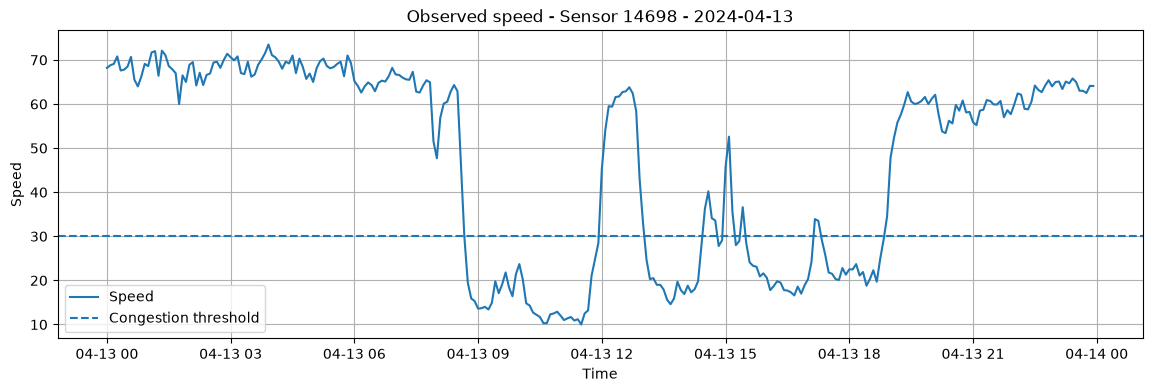

In [39]:

plt.figure(figsize=(14, 4))

plt.plot(day_alerts["timestamp"], day_alerts["speed"], label="Speed")
plt.axhline(30, linestyle="--", label="Congestion threshold")

plt.title(f"Observed speed - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.legend()
plt.grid(True)

plt.show()

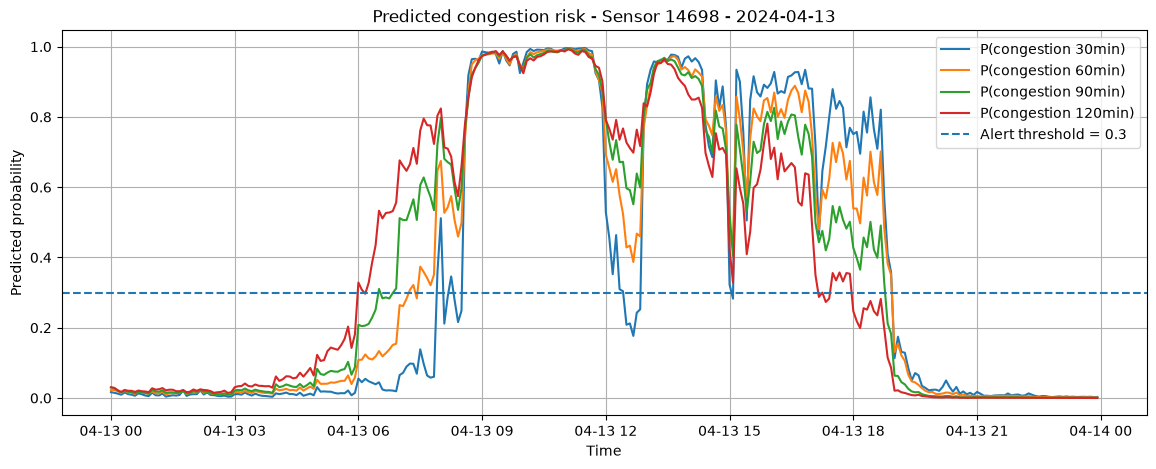

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(day_alerts["timestamp"], day_alerts["proba_30min"], label="P(congestion 30min)")
plt.plot(day_alerts["timestamp"], day_alerts["proba_60min"], label="P(congestion 60min)")
plt.plot(day_alerts["timestamp"], day_alerts["proba_90min"], label="P(congestion 90min)")
plt.plot(day_alerts["timestamp"], day_alerts["proba_120min"], label="P(congestion 120min)")

plt.axhline(OPERATIONAL_THRESHOLD, linestyle="--", label=f"Alert threshold = {OPERATIONAL_THRESHOLD}")

plt.title(f"Predicted congestion risk - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Predicted probability")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
from xgboost import XGBClassifier

xgb_models = {}
xgb_results = []

for target in target_cols:
    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    xgb_models[target] = model

    xgb_results.append({
        "target": target,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "positive_rate_true": y_test.mean(),
        "positive_rate_pred": y_pred.mean()
    })

xgb_results_df = pd.DataFrame(xgb_results)

xgb_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred
0,congestion_30min,0.901337,0.731562,0.839140,0.781667,0.963109,0.210472,0.241422
1,congestion_60min,0.860443,0.619497,0.872840,0.724665,0.951419,0.210408,0.296455
2,congestion_90min,0.845543,0.588762,0.881192,0.705889,0.944252,0.210345,0.314820
3,congestion_120min,0.838654,0.574576,0.896482,0.700308,0.943792,0.210282,0.328092


In [42]:
model_comparison = logreg_results_df.merge(
    xgb_results_df,
    on="target",
    suffixes=("_logreg", "_xgb")
)

model_comparison[
    [
        "target",
        "accuracy_logreg",
        "accuracy_xgb",
        "precision_logreg",
        "precision_xgb",
        "recall_logreg",
        "recall_xgb",
        "f1_logreg",
        "f1_xgb",
        "roc_auc_logreg",
        "roc_auc_xgb"
    ]
]

,target,accuracy_logreg,accuracy_xgb,precision_logreg,precision_xgb,recall_logreg,recall_xgb,f1_logreg,f1_xgb,roc_auc_logreg,roc_auc_xgb
0,congestion_30min,0.821261,0.901337,0.542660,0.731562,0.958932,0.839140,0.693096,0.781667,0.953857,0.963109
1,congestion_60min,0.806816,0.860443,0.523243,0.619497,0.921404,0.872840,0.667455,0.724665,0.929471,0.951419
2,congestion_90min,0.801754,0.845543,0.516277,0.588762,0.912238,0.881192,0.659380,0.705889,0.913703,0.944252
3,congestion_120min,0.798975,0.838654,0.512284,0.574576,0.917889,0.896482,0.657571,0.700308,0.906515,0.943792


In [43]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

xgb_early_results = []

for target in target_cols:
    model = xgb_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    xgb_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

xgb_early_results_df = pd.DataFrame(xgb_early_results)

xgb_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.918593,0.279313,0.463401,0.348543,0.905463,0.046994,0.077967,74711
1,congestion_60min,0.873044,0.297104,0.656469,0.409071,0.907926,0.066938,0.147903,74711
2,congestion_90min,0.859472,0.345106,0.725271,0.467677,0.912086,0.085115,0.178876,74711
3,congestion_120min,0.852994,0.389336,0.811095,0.526125,0.923529,0.100614,0.209608,74711


In [44]:
import matplotlib.pyplot as plt
import numpy as np

target = "congestion_60min"

model = xgb_models[target]

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importances.head(20)

,feature,importance
1,occupancy,0.458103
18,occupancy_lag_5m,0.132995
38,occupancy_roll_mean_30m,0.098521
34,occupancy_roll_mean_15m,0.051095
24,occupancy_lag_30m,0.046735
4,hour,0.020079
3,is_congested,0.016616
2,speed,0.016061
10,hour_cos,0.014738
9,hour_sin,0.012397


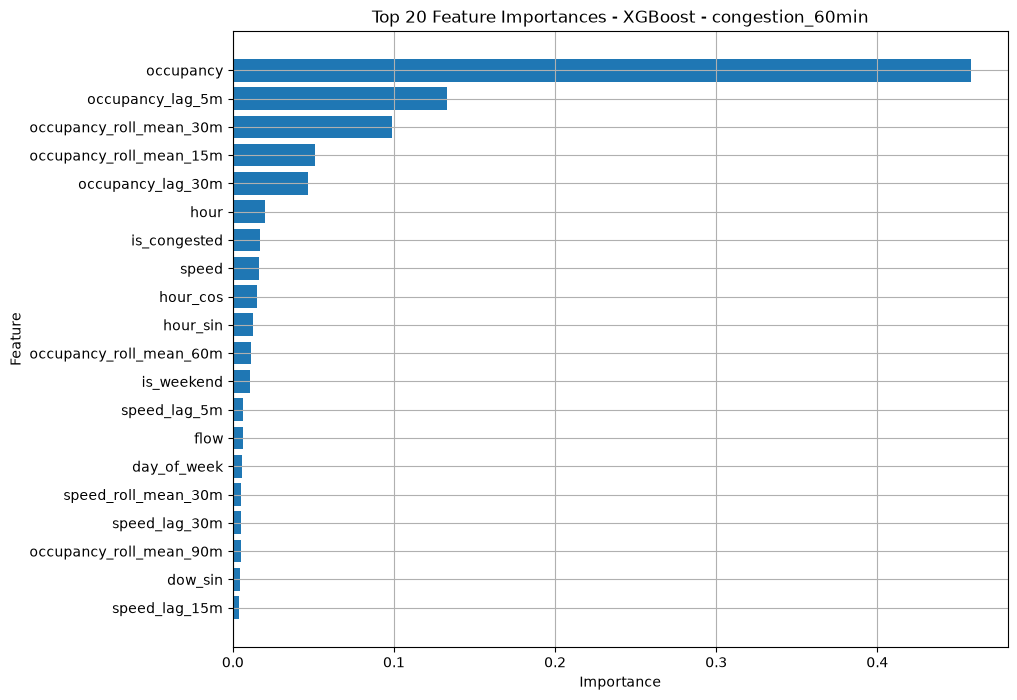

In [45]:
top_n = 20

top_features = importances.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances - XGBoost - {target}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

In [46]:
OPERATIONAL_THRESHOLD = 0.30

df_alerts_xgb = test_df.copy()
df_alerts_xgb["timestamp"] = pd.to_datetime(df_alerts_xgb["timestamp"])

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = xgb_models[target]

    proba_col = f"xgb_proba_{horizon}"
    alert_col = f"xgb_alert_{horizon}"

    df_alerts_xgb[proba_col] = model.predict_proba(
        df_alerts_xgb[feature_cols]
    )[:, 1]

    df_alerts_xgb[alert_col] = (
        df_alerts_xgb[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts_xgb.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,xgb_proba_30min,xgb_alert_30min,xgb_proba_60min,xgb_alert_60min,xgb_proba_90min,xgb_alert_90min,xgb_proba_120min,xgb_alert_120min
220812,139.0,0.4181,8.1,2024-02-07 07:45:00,14698,819086,2024-02-07,1,1.0,1.0,...,0.0063,-0.0022,0.998506,1,0.994481,1,0.970034,1,0.898557,1
220813,155.0,0.4043,8.2,2024-02-07 07:50:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0138,-0.0211,0.998421,1,0.994083,1,0.968149,1,0.899651,1
220814,152.0,0.3438,9.1,2024-02-07 07:55:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0605,-0.0680,0.998215,1,0.992859,1,0.958280,1,0.884358,1
220815,136.0,0.3991,8.3,2024-02-07 08:00:00,14698,819086,2024-02-07,1,1.0,1.0,...,0.0553,-0.0190,0.997515,1,0.975956,1,0.951302,1,0.898993,1
220816,152.0,0.3950,20.1,2024-02-07 08:05:00,14698,819086,2024-02-07,1,1.0,1.0,...,-0.0041,-0.0093,0.973006,1,0.913071,1,0.904156,1,0.862894,1


In [47]:
daily_test_summary = (
    df_alerts_xgb
    .groupby(df_alerts_xgb["timestamp"].dt.date)
    .agg(
        avg_speed=("speed", "mean"),
        min_speed=("speed", "min"),
        slow_rate_30=("speed", lambda x: (x < 30).mean()),
        n_rows=("speed", "count")
    )
    .reset_index(names="date")
)

daily_test_summary.sort_values("slow_rate_30", ascending=False).head(10)

,date,avg_speed,min_speed,slow_rate_30,n_rows
86,2024-05-03,35.640972,7.4,0.597222,288
16,2024-02-23,35.193056,8.6,0.597222,288
317,2024-12-20,35.880208,7.1,0.579861,288
9,2024-02-16,37.665625,9.7,0.572917,288
65,2024-04-12,35.847222,7.8,0.548611,288
49,2024-03-27,38.756597,7.8,0.545139,288
2,2024-02-09,38.963194,8.3,0.541667,288
23,2024-03-01,38.502778,10.4,0.541667,288
30,2024-03-08,38.499653,9.3,0.538194,288
20,2024-02-27,38.018403,7.0,0.538194,288


In [48]:
selected_day = pd.Timestamp(
    daily_test_summary
    .sort_values("slow_rate_30", ascending=False)
    .iloc[0]["date"]
)

day_alerts = df_alerts_xgb[
    (df_alerts_xgb["timestamp"] >= selected_day) &
    (df_alerts_xgb["timestamp"] < selected_day + pd.Timedelta(days=1))
].copy()

print(day_alerts.shape)

(288, 68)


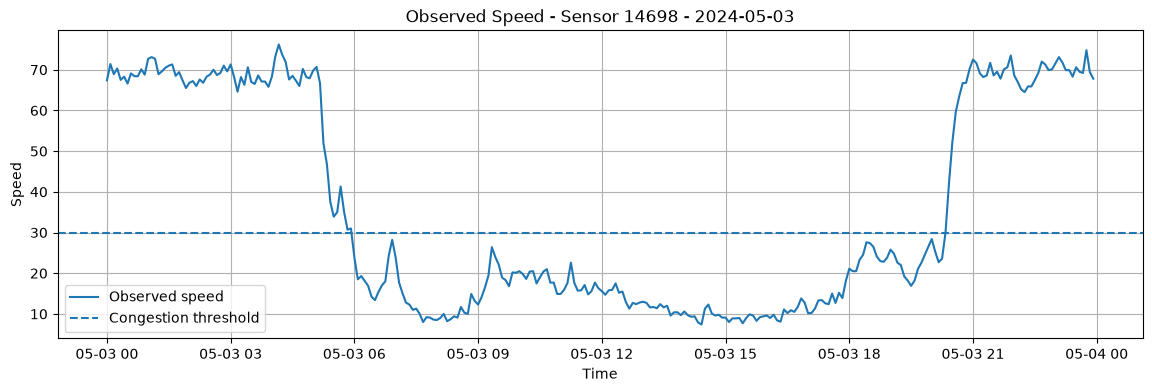

In [54]:
plt.figure(figsize=(14, 4))

plt.plot(day_alerts["timestamp"], day_alerts["speed"], label="Observed speed")
plt.axhline(30, linestyle="--", label="Congestion threshold")

plt.title(f"Observed Speed - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.legend()
plt.grid(True)

plt.show()

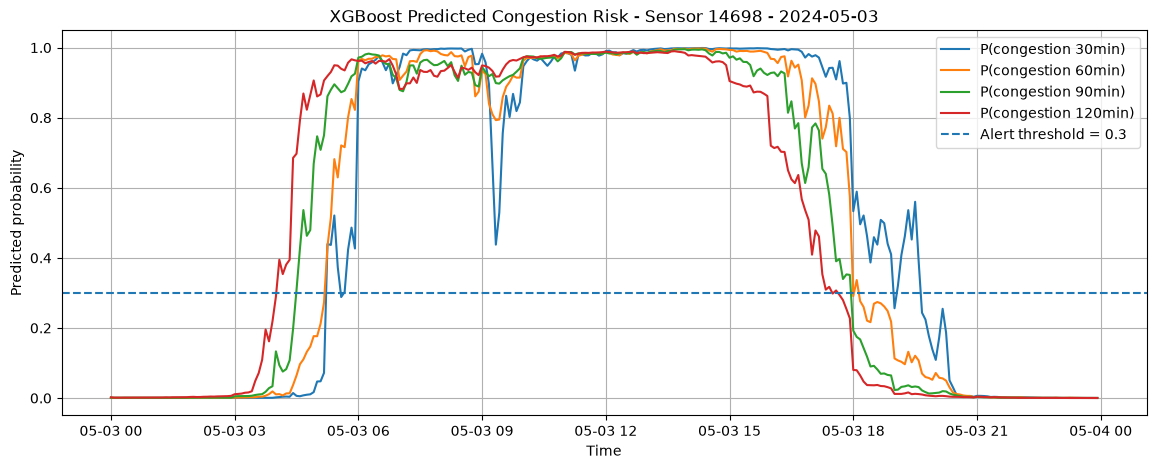

In [50]:
plt.figure(figsize=(14, 5))

plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_30min"], label="P(congestion 30min)")
plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_60min"], label="P(congestion 60min)")
plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_90min"], label="P(congestion 90min)")
plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_120min"], label="P(congestion 120min)")

plt.axhline(OPERATIONAL_THRESHOLD, linestyle="--", label=f"Alert threshold = {OPERATIONAL_THRESHOLD}")

plt.title(f"XGBoost Predicted Congestion Risk - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Predicted probability")
plt.legend()
plt.grid(True)

plt.show()

In [51]:
target = "congestion_60min"

model = xgb_models[target]

xgb_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importances.head(20)

,feature,importance
1,occupancy,0.458103
18,occupancy_lag_5m,0.132995
38,occupancy_roll_mean_30m,0.098521
34,occupancy_roll_mean_15m,0.051095
24,occupancy_lag_30m,0.046735
4,hour,0.020079
3,is_congested,0.016616
2,speed,0.016061
10,hour_cos,0.014738
9,hour_sin,0.012397


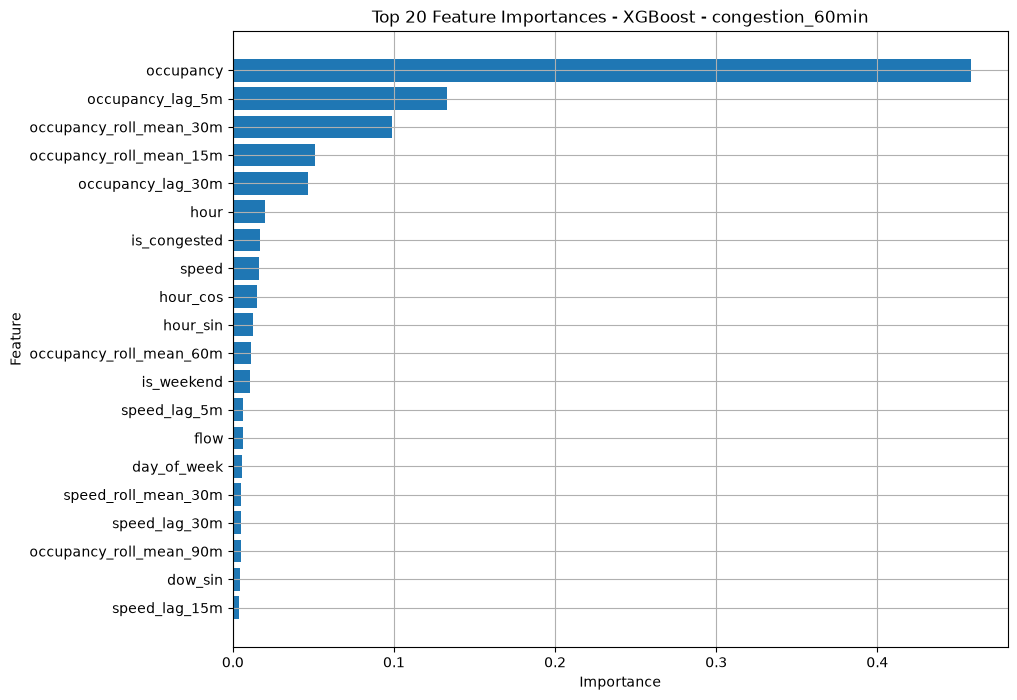

In [52]:
top_features = xgb_importances.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])

plt.title(f"Top 20 Feature Importances - XGBoost - {target}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)

plt.show()